<h1>Emmanuel M. Aviles | Accident Activity</h1>

<h2> 1. Imports </h2>

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

<h2>2. Data </h2>

In [2]:
df = pd.read_csv('uk_road_accident.csv')
df

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200701BS64157,Serious,5/6/2019,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car
1,200701BS65737,Serious,2/7/2019,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
2,200701BS66127,Serious,26-08-2019,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car
3,200701BS66128,Serious,16-08-2019,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,200701BS66837,Slight,3/9/2019,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,18-02-2022,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car
660675,201091NM01881,Slight,21-02-2022,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660676,201091NM01935,Slight,23-02-2022,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660677,201091NM01964,Serious,23-02-2022,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc


In [3]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')

In [4]:
df['Month'] = df['Accident Date'].dt.month
df['DayOfWeek'] = df['Accident Date'].dt.day_name()

<h2>3.Data Information</h2>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  object        
 1   Accident_Severity        660679 non-null  object        
 2   Accident Date            265007 non-null  datetime64[ns]
 3   Latitude                 660654 non-null  float64       
 4   Light_Conditions         660679 non-null  object        
 5   District Area            660679 non-null  object        
 6   Longitude                660653 non-null  float64       
 7   Number_of_Casualties     660679 non-null  int64         
 8   Number_of_Vehicles       660679 non-null  int64         
 9   Road_Surface_Conditions  659953 non-null  object        
 10  Road_Type                656159 non-null  object        
 11  Urban_or_Rural_Area      660664 non-null  object        
 12  Weather_Conditio

<h2>4. Basic Descriptive Statistics</h2>

In [6]:
df.describe()

,Accident Date,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Month
count,265007,660654.000000,660653.000000,660679.000000,660679.000000,265007.000000
mean,2020-11-18 04:53:34.375468544,52.553866,-1.431210,1.357040,1.831255,6.522028
min,2019-01-01 00:00:00,49.914430,-7.516225,1.000000,1.000000,1.000000
25%,2019-12-02 00:00:00,51.490690,-2.332291,1.000000,1.000000,4.000000
50%,2020-11-05 00:00:00,52.315641,-1.411667,1.000000,2.000000,7.000000
75%,2021-11-05 00:00:00,53.453452,-0.232869,1.000000,2.000000,10.000000
max,2022-12-12 00:00:00,60.757544,1.762010,68.000000,32.000000,12.000000
std,NaN,1.406922,1.383330,0.824847,0.715269,3.467063


<h2>5. Checking Null Values</h2>

In [7]:
df.isnull().sum()

Index                           0
Accident_Severity               0
Accident Date              395672
Latitude                       25
Light_Conditions                0
District Area                   0
Longitude                      26
Number_of_Casualties            0
Number_of_Vehicles              0
Road_Surface_Conditions       726
Road_Type                    4520
Urban_or_Rural_Area            15
Weather_Conditions          14128
Vehicle_Type                    0
Month                      395672
DayOfWeek                  395672
dtype: int64

<h2>6. Filling Null Values</h2>

In [8]:
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mode()[0])
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].mode()[0])
df['Road_Surface_Conditions'] = df['Road_Surface_Conditions'].fillna(df['Road_Surface_Conditions'].mode()[0])
df['Road_Type'] = df['Road_Type'].fillna(df['Road_Type'].mode()[0])
df['Urban_or_Rural_Area'] = df['Urban_or_Rural_Area'].fillna(df['Urban_or_Rural_Area'].mode()[0])
df['Weather_Conditions'] = df['Weather_Conditions'].fillna(df['Weather_Conditions'].mode()[0])

In [9]:
df.isnull().sum()

Index                           0
Accident_Severity               0
Accident Date              395672
Latitude                        0
Light_Conditions                0
District Area                   0
Longitude                       0
Number_of_Casualties            0
Number_of_Vehicles              0
Road_Surface_Conditions         0
Road_Type                       0
Urban_or_Rural_Area             0
Weather_Conditions              0
Vehicle_Type                    0
Month                      395672
DayOfWeek                  395672
dtype: int64

<h2>7. Checking Data Columns</h2>

In [10]:
df.dtypes

Index                              object
Accident_Severity                  object
Accident Date              datetime64[ns]
Latitude                          float64
Light_Conditions                   object
District Area                      object
Longitude                         float64
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions            object
Road_Type                          object
Urban_or_Rural_Area                object
Weather_Conditions                 object
Vehicle_Type                       object
Month                             float64
DayOfWeek                          object
dtype: object

In [11]:
df

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Month,DayOfWeek
0,200701BS64157,Serious,2019-05-06,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,5.0,Monday
1,200701BS65737,Serious,2019-02-07,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car,2.0,Thursday
2,200701BS66127,Serious,NaT,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,Single carriageway,Urban,Fine no high winds,Taxi/Private hire car,NaN,NaN
3,200701BS66128,Serious,NaT,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats),NaN,NaN
4,200701BS66837,Slight,2019-03-09,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,Single carriageway,Urban,Fine no high winds,Other vehicle,3.0,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,NaT,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car,NaN,NaN
660675,201091NM01881,Slight,NaT,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car,NaN,NaN
660676,201091NM01935,Slight,NaT,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car,NaN,NaN
660677,201091NM01964,Serious,NaT,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc,NaN,NaN


<h1>20 QUESTIONS AND 20 INSIGHTS</h1>

<H2>1. What is the distribution of accident severity overall?</H2>

In [12]:
df['Accident_Severity'].value_counts(normalize=True)

Accident_Severity
Slight     0.853366
Serious    0.133525
Fatal      0.013109
Name: proportion, dtype: float64

<h2>Insights: The severity of the accidents are divided into 3, it was slight,serious and fatal according to the result most of the time casualty of the accidents was only minor but still there are serious and fatal damage to some accidents. </h2>

<h2>2. Which district has the most accidents?</h2>

In [13]:
df['District Area'].value_counts()

District Area
Birmingham            13491
Leeds                  8898
Manchester             6720
Bradford               6212
Sheffield              5710
                      ...  
Berwick-upon-Tweed      153
Teesdale                142
Shetland Islands        133
Orkney Islands          117
Clackmannanshire         91
Name: count, Length: 422, dtype: int64

<h2>Insights: It shows that among the districts that noted in this data Birmingham surpass the others accidents by far, It has 13,491 and the following was only 8898 Leeds District. </h2>

<h2>3. What time of year has the most accidents?</h2>

In [14]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'])
df['Month'] = df['Accident Date'].dt.month
df['Month'].value_counts().sort_index()

Month
1.0     22606
2.0     21815
3.0     21540
4.0     21699
5.0     22409
6.0     21974
7.0     21431
8.0     21914
9.0     22252
10.0    22328
11.0    22503
12.0    22536
Name: count, dtype: int64

<h2>Insights: The accidents that occured throughout the year, but the highest number occurs in January (22606), followed closely by December (22536) and November (22503). These months fall in the winter season, which may worsening weather conditions, shorter daylight hours, and increased accident risk during this time of year. </h2>

<h2>4. How does weather affect accident severity?</h2>

In [15]:
df.groupby('Weather_Conditions')['Accident_Severity'].value_counts(normalize=True)* 100

Weather_Conditions     Accident_Severity
Fine + high winds      Slight               83.399579
                       Serious              14.554594
                       Fatal                 2.045827
Fine no high winds     Slight               84.955132
                       Serious              13.697798
                       Fatal                 1.347070
Fog or mist            Slight               83.985261
                       Serious              13.690476
                       Fatal                 2.324263
Other                  Slight               88.536443
                       Serious              10.501458
                       Fatal                 0.962099
Raining + high winds   Slight               85.377015
                       Serious              13.114925
                       Fatal                 1.508060
Raining no high winds  Slight               87.055812
                       Serious              11.880145
                       Fatal             

<h2>Insights: Accidents that occur during fog or mist have the highest proportion of fatal outcomes which indicates that reduced visibility is a significant risk factor for severe accidents. </h2>

<h2>Insights: And accidents that occur during snowing + high winds are the least fatal accidents because when you check number 9 it only has 90 accidents total which means drivers on these events are in their home or very careful while driving. </h2>

<h2>5. Which one do more accidents? is it urban or rural areas?</h2>

In [16]:
df['Urban_or_Rural_Area'].value_counts()

Urban_or_Rural_Area
Urban          421678
Rural          238990
Unallocated        11
Name: count, dtype: int64

<h2>Insights: According to the outcome of the data there are more accidents in Urban Areas, Base on that we can assume that, because it is more populated than Rural. </h2>

<h2>Insights: But according to number 14 rural has more fatality so it means most of urban percentage accidents are minor and serious. Because it is more populated than rural areas </h2>

<H2>6. What light conditions are most dangerous?</H2>

In [17]:
df.groupby('Light_Conditions')['Accident_Severity'].value_counts(normalize=True)* 100

Light_Conditions             Accident_Severity
Darkness - lighting unknown  Slight               86.705737
                             Serious              12.245527
                             Fatal                 1.048735
Darkness - lights lit        Slight               83.770828
                             Serious              14.791047
                             Fatal                 1.438126
Darkness - lights unlit      Slight               84.073928
                             Serious              14.156508
                             Fatal                 1.769564
Darkness - no lighting       Slight               76.531239
                             Serious              19.162860
                             Fatal                 4.305901
Daylight                     Slight               86.422414
                             Serious              12.530729
                             Fatal                 1.046857
Name: proportion, dtype: float64

<h2>Insights: The most dangerous light condition is "Darkness - no lighting", which has the highest proportion of fatal accidents than the other light conditions.</h2>

<h2>7. Which road types see the most severe accidents? </h2>

In [18]:
df.groupby('Road_Type')['Accident_Severity'].value_counts(normalize=True)* 100

Road_Type           Accident_Severity
Dual carriageway    Slight               86.360436
                    Serious              11.814049
                    Fatal                 1.825515
One way street      Slight               87.093443
                    Serious              12.205915
                    Fatal                 0.700642
Roundabout          Slight               91.346154
                    Serious               8.331060
                    Fatal                 0.322786
Single carriageway  Slight               84.476395
                    Serious              14.202789
                    Fatal                 1.320815
Slip road           Slight               90.626331
                    Serious               8.677745
                    Fatal                 0.695924
Name: proportion, dtype: float64

<h2>Insights: Single carriageways have the highest percentage of serious accidents compared to other road types, indicating these roads are relatively more dangerous in terms of accident severity.</h2>

<h2>8. What vehicle types are involved in the most accidents? </h2>

In [19]:
df['Vehicle_Type'].value_counts()

Vehicle_Type
Car                                      497992
Van / Goods 3.5 tonnes mgw or under       34160
Bus or coach (17 or more pass seats)      25878
Motorcycle over 500cc                     25657
Goods 7.5 tonnes mgw and over             17307
Motorcycle 125cc and under                15269
Taxi/Private hire car                     13294
Motorcycle over 125cc and up to 500cc      7656
Motorcycle 50cc and under                  7603
Goods over 3.5t. and under 7.5t            6096
Other vehicle                              5637
Minibus (8 - 16 passenger seats)           1976
Agricultural vehicle                       1947
Pedal cycle                                 197
Data missing or out of range                  6
Ridden horse                                  4
Name: count, dtype: int64

<h2>Insights: Cars have the highest percentage of serious accidents compared to other vehicle types, and it is followed by van but it has a very wide margin among the others.</h2>

<h2>9. Is there a relationship between vehicle type and casualties?</h2>

In [20]:
df.groupby('Vehicle_Type')['Number_of_Casualties'].count()

Vehicle_Type
Agricultural vehicle                       1947
Bus or coach (17 or more pass seats)      25878
Car                                      497992
Data missing or out of range                  6
Goods 7.5 tonnes mgw and over             17307
Goods over 3.5t. and under 7.5t            6096
Minibus (8 - 16 passenger seats)           1976
Motorcycle 125cc and under                15269
Motorcycle 50cc and under                  7603
Motorcycle over 125cc and up to 500cc      7656
Motorcycle over 500cc                     25657
Other vehicle                              5637
Pedal cycle                                 197
Ridden horse                                  4
Taxi/Private hire car                     13294
Van / Goods 3.5 tonnes mgw or under       34160
Name: Number_of_Casualties, dtype: int64

<h2>Insights: Cars being the most common vehicle type, also contribute the largest number of casualties overall. This aligns with their dominant presence on the roads. </h2>

<h2>10. Which day(s) of the week have the most accidents?</h2>

In [21]:
df['Day Of Week'] = df['Accident Date'].dt.day_name()
df['Day Of Week'].value_counts()

Day Of Week
Tuesday      39701
Friday       38511
Thursday     38009
Sunday       37772
Saturday     37751
Wednesday    37548
Monday       35715
Name: count, dtype: int64

<h2>Insights: Tuesday records the highest number of accidents (39,701), It's followed by Friday (38,511) and Thursday (38,009).
and weekends (Saturday and Sunday) also show high accident counts both around 37,700 . Monday has the fewest accidents (35,715), well maybe because people are not yet on the mood to work that drains them.</h2>

<h2>11. Do accidents happens in the same geographic areas?</h2>

In [22]:
df['Lat_Lon'] = df[['Latitude', 'Longitude']].round(3).astype(str).agg(','.join, axis=1)
df['Lat_Lon'].value_counts().head(10)

Lat_Lon
52.459,-1.871    66
51.461,-0.116    58
51.571,-0.096    56
51.495,-0.101    53
52.473,-1.875    51
51.59,-0.2       50
51.474,-0.093    48
51.525,-0.035    47
51.52,-0.056     45
52.95,-0.978     45
Name: count, dtype: int64

<h2>Insights: Yes there was some occurence of the accident happens on the same place.</h2>

<h2>12. Is there any road conditions that are more dangerous? </h2>

In [23]:
df.groupby('Road_Surface_Conditions')['Accident_Severity'].value_counts(normalize=True)* 100

Road_Surface_Conditions  Accident_Severity
Dry                      Slight               84.951856
                         Serious              13.757310
                         Fatal                 1.290835
Flood over 3cm. deep     Slight               82.792527
                         Serious              14.945919
                         Fatal                 2.261554
Frost or ice             Slight               88.119026
                         Serious              10.838689
                         Fatal                 1.042285
Snow                     Slight               89.813243
                         Serious               9.592530
                         Fatal                 0.594228
Wet or damp              Slight               85.857596
                         Serious              12.739143
                         Fatal                 1.403261
Name: proportion, dtype: float64

<h2>Insights: The data shows that Flood over 3cm deep is the most dangerous road surface condition, with the highest fatal accident rate at 2.26%, which is above compare to other conditions. It also has a high serious accident rate (14.95%), making it the most severe overall.</h2>

<h2>Insights: and the most least was the snow which is kinda confusing because we know there are several effects of snowing like slippery roads, snow vision and etc. But we can also think that its the most least fatal because vehicles on that day mostly don't go out.</h2>

<h2>13. How many casualties occur per accident on average?</h2>

In [24]:
df['Number_of_Casualties'].mean()

np.float64(1.357040257068864)

<h2>Insights: The data shows that Flood over 3cm deep is the most dangerous road surface condition, with the highest fatal accident rate at 2.26%, which is above compare to other conditions. It also has a high serious accident rate (14.95%), making it the most severe overall.</h2>

<h2>14. Are fatal accidents more common in rural areas?</h2>

In [25]:
rural_fatal = df[(df['Urban_or_Rural_Area'] == 'Rural') & (df['Accident_Severity'] == 'Fatal')]
len(rural_fatal)

5601

In [26]:
rural_fatal = df[(df['Urban_or_Rural_Area'] == 'Urban') & (df['Accident_Severity'] == 'Fatal')]
len(rural_fatal)

3060

<h2>Insights: Yes there is base on the outcome the rural has the 5601 fatal accidents and the urban has 3060 fatal crashes even though urban area is more populated area than rural, accidents that happen in rural at is a has more fatality then urban we can assume that the road conditions is not maintained because it is outside and city, not always notice by the people, light condition in the post are weak it does not give much visibility, weather are more violent because no buildings will block it and most of the time overspeeding because rural area roads have much faster pacing because its not crowded.

<h2>15. Which weather condition had the most vehicle accidents?</h2>

In [27]:
df[df['Number_of_Vehicles'] > 2].groupby('Weather_Conditions').size()

Weather_Conditions
Fine + high winds          853
Fine no high winds       54556
Fog or mist                420
Other                     1628
Raining + high winds      1032
Raining no high winds     8672
Snowing + high winds        90
Snowing no high winds      646
dtype: int64

<h2>Insights: Base on the outcome "Fine no high winds" is the weather condition associated with by far the most vehicle accidents followed by Raining no winds. It has more crashes because more cars often drive on that weather.</h2>

<h2>Insights: Which is kinda because we know that snowing + highwinds suppose to be the very dangerous weather to drive and yet it was only 90 we can assume that people are not dumb enough to drive through this weather condition.</h2>


<h2>16. What’s the correlation between number of vehicles and severity?</h2>

In [28]:
df[['Number_of_Vehicles', 'Number_of_Casualties']].corr()

,Number_of_Vehicles,Number_of_Casualties
Number_of_Vehicles,1.000000,0.228889
Number_of_Casualties,0.228889,1.000000


<h2>Insights: There are no correlation on these two or we can say it has a weak correlation that cant be consider correlated. </h2>

<h2>17. Are there specific districts with unusual accident types or frequencies?</h2>

In [29]:
df.groupby('District Area')['Accident_Severity'].value_counts().unstack().fillna(0).astype(int)

Accident_Severity,Fatal,Serious,Slight
District Area,,,
Aberdeen City,12,239,1072
Aberdeenshire,66,463,1401
Adur,8,101,510
Allerdale,24,143,961
Alnwick,6,33,193
...,...,...,...
Wychavon,30,193,1138
Wycombe,20,216,1493
Wyre,15,186,1037


<h2>Insights: The Aberdeenshire shows a high number of fatal accidents than other districts which means rural road conditions, speeding, or access issues to emergency services.</h2>

<h2>18. Is accident severity seasonal?</h2>

In [30]:
df.groupby('Month')['Accident_Severity'].value_counts(normalize=True)* 100

Month  Accident_Severity
1.0    Slight               85.198620
       Serious              13.483146
       Fatal                 1.318234
2.0    Slight               85.968370
       Serious              12.693101
       Fatal                 1.338529
3.0    Slight               85.338904
       Serious              13.259053
       Fatal                 1.402043
4.0    Slight               85.285036
       Serious              13.401539
       Fatal                 1.313425
5.0    Slight               85.644161
       Serious              13.110804
       Fatal                 1.245035
6.0    Slight               85.628470
       Serious              12.978975
       Fatal                 1.392555
7.0    Slight               85.520974
       Serious              13.191172
       Fatal                 1.287854
8.0    Slight               85.488729
       Serious              13.224423
       Fatal                 1.286849
9.0    Slight               85.196836
       Serious           

<h2>Insights: The accidents percentage every months are stable there are only slight fluctuations we can assume that it is because there weather,road conditions, and light conditions that month.</h2>

<h2>19. What is the average number of casualties per vehicle type?</h2>

In [31]:
df.groupby('Vehicle_Type')['Number_of_Casualties'].mean().sort_values(ascending=False)

Vehicle_Type
Data missing or out of range             1.500000
Pedal cycle                              1.370558
Taxi/Private hire car                    1.368663
Goods over 3.5t. and under 7.5t          1.362861
Motorcycle over 500cc                    1.359434
Car                                      1.358841
Van / Goods 3.5 tonnes mgw or under      1.354537
Goods 7.5 tonnes mgw and over            1.351881
Bus or coach (17 or more pass seats)     1.349216
Minibus (8 - 16 passenger seats)         1.345648
Motorcycle over 125cc and up to 500cc    1.343521
Agricultural vehicle                     1.342065
Other vehicle                            1.340075
Motorcycle 50cc and under                1.337235
Motorcycle 125cc and under               1.332635
Ridden horse                             1.250000
Name: Number_of_Casualties, dtype: float64

<h2>Insights: Pedal cycles and taxis/private hire cars have among the highest averages means the vulnerability of these vehicles or passenger numbers. </h2>

<h2>Insights: And the least is the horse because it only hits 1.25 percent and it only has a tally of 4 horse accidents over the years.</h2>

<h2>20. How do accidents vary with day/night light conditions in rural vs. urban areas?</h2>

In [32]:
accidents_by_light_area = df.groupby(['Urban_or_Rural_Area', 'Light_Conditions']).size().unstack(fill_value=0)
accidents_by_light_area

Light_Conditions,Darkness - lighting unknown,Darkness - lights lit,Darkness - lights unlit,Darkness - no lighting,Daylight
Urban_or_Rural_Area,,,,,
Rural,2467,24695,961,35517,175350
Unallocated,0,2,0,0,9
Urban,4017,104638,1582,1920,309521


<h2>Insights: Most accidents happen during daylight especially in urban areas (309521) , but in rural areas the number of accidents in complete darkness with no lighting is very high too (35517) this only means that light post in rural areas cant cover there coverages.</h2>

<h1>Install Folium</h1>

In [33]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


<h1>Check Dataframe</h1>

In [34]:
print(df['District Area'].unique())

['Kensington and Chelsea' 'Westminster' 'Richmond upon Thames'
 'Hammersmith and Fulham' 'Hounslow' 'Tower Hamlets' 'City of London'
 'Southwark' 'Camden' 'Hackney' 'Islington' 'Barnet' 'Brent' 'Haringey'
 'Merton' 'Ealing' 'Enfield' 'Greenwich' 'Newham'
 'London Airport (Heathrow)' 'Hillingdon' 'Waltham Forest' 'Redbridge'
 'Barking and Dagenham' 'Bromley' 'Havering' 'Croydon' 'Lambeth'
 'Wandsworth' 'Sutton' 'Bexley' 'Lewisham' 'Harrow' 'Kingston upon Thames'
 'Barrow-in-Furness' 'South Lakeland' 'Carlisle' 'Eden' 'Allerdale'
 'Copeland' 'Fylde' 'Blackpool' 'Wyre' 'Lancaster' 'Chorley'
 'West Lancashire' 'South Ribble' 'Preston' 'Blackburn with Darwen'
 'Hyndburn' 'Ribble Valley' 'Burnley' 'Pendle' 'Rossendale' 'Wirral'
 'Liverpool' 'Sefton' 'Knowsley' 'St. Helens' 'Manchester' 'Salford'
 'Tameside' 'Stockport' 'Bolton' 'Wigan' 'Trafford' 'Bury' 'Rochdale'
 'Oldham' 'Chester' 'Vale Royal' 'Halton' 'Warrington' 'Crewe and ntwich'
 'Ellesmere Port and Neston' 'Congleton' 'Macclesfield'

In [35]:
import folium
from folium.plugins import HeatMap

<h1> Glasgow City Heatmap Analysis</h1>

In [36]:
glasgow_df = df[df['District Area'] == 'Glasgow City']
locations = list(zip(glasgow_df['Latitude'], glasgow_df['Longitude']))

m = folium.Map(
    location=[glasgow_df['Latitude'].mean(), glasgow_df['Longitude'].mean()],
    zoom_start=10
)
HeatMap(locations).add_to(m)

m.save('accident_heatmap.html')
m

<h2>Insight: From what I observed every corner of the Glasgow City has a car accident that happen we can assume that this accidents is everywhere because this district is a city, a very developed one it just means that road is everywhere.</h>

<h1> Glasgow City "Fatal accidents" Heatmap Analysis</h1>

In [37]:
glasgow_fatal_df = df[
    (df['District Area'] == 'Glasgow City') &
    (df['Accident_Severity'] == 'Fatal')
]

locations = list(zip(glasgow_fatal_df['Latitude'], glasgow_fatal_df['Longitude']))

m = folium.Map(
    location=[glasgow_fatal_df['Latitude'].mean(), glasgow_fatal_df['Longitude'].mean()],
    zoom_start=10
)

HeatMap(locations).add_to(m)

m.save('accident_heatmap.html')
m

<h2>Insight: I revised the code so it can only show "fatal" accident hotspots. From what I deduce from the data given by the heatmap most accidents occurs on a intersection which is very common to a well developed country, but this thing should not occur because intersection are where stoplights do reside. Inshort we can assume that most of this fatal accidents are human error cause of reckless driving.</h>

<h1>Blackpool Analysis</h1>

In [38]:
blackpool_df = df[df['District Area'] == 'Blackpool']

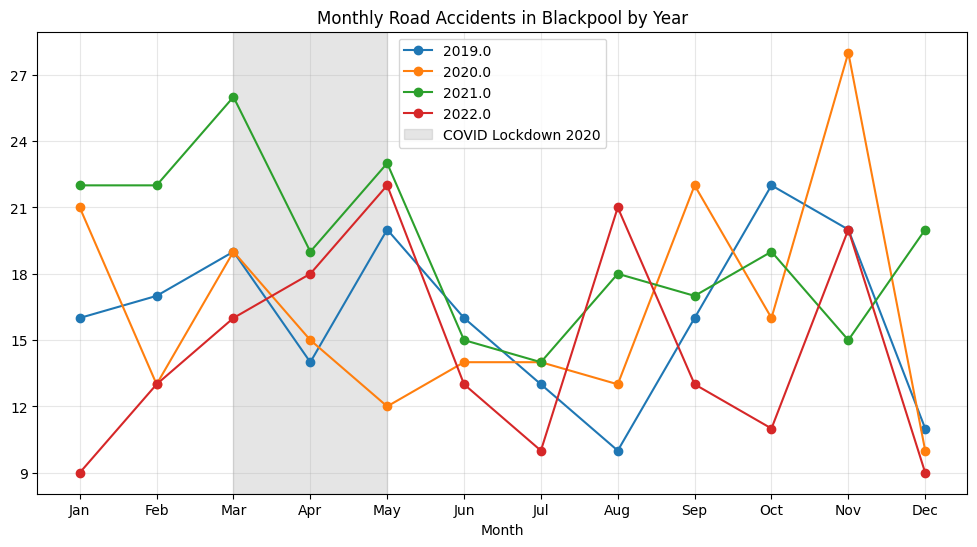

In [39]:
blackpool_df['Accident Date'] = pd.to_datetime(blackpool_df['Accident Date'])
blackpool_df['Year'] = blackpool_df['Accident Date'].dt.year
blackpool_df['Month'] = blackpool_df['Accident Date'].dt.month

monthly_blackpool = blackpool_df.groupby(['Month', 'Year']).size().unstack(level=1)
monthly_blackpool = monthly_blackpool.reindex(range(1, 13))

ax = monthly_blackpool.plot(
    marker='o',
    figsize=(12, 6),
    title='Monthly Road Accidents in Blackpool by Year'
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax.axvspan(3, 5, color='grey', alpha=0.2, label="COVID Lockdown 2020")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

<h2>Insight: This is the monthly road accidents in Blackpool that is according to my research the poorest and worst road condition in the data. As we can see their accidents are not consistent which means there are several reasons that caused this accidents. In the graph there is a gray shade means covid lockdown according to my legend. But even it is lockdown the accidents are still occuring. And the year 2019,2020,2022 noticably dipped down when month of december came which was the opposite of what Im expecting because we knew that Snow,Strong North Winds and etc occurs by that time.   </h2>

<h2> Insight: We can also notice that by 2022 Jan and Dec hit their lowest at 9 what a count to start the year and to end it xD and also we can noticed that they reached their peak at 2020 November we can assume that there is an event related to halloween that cause this. </h2>

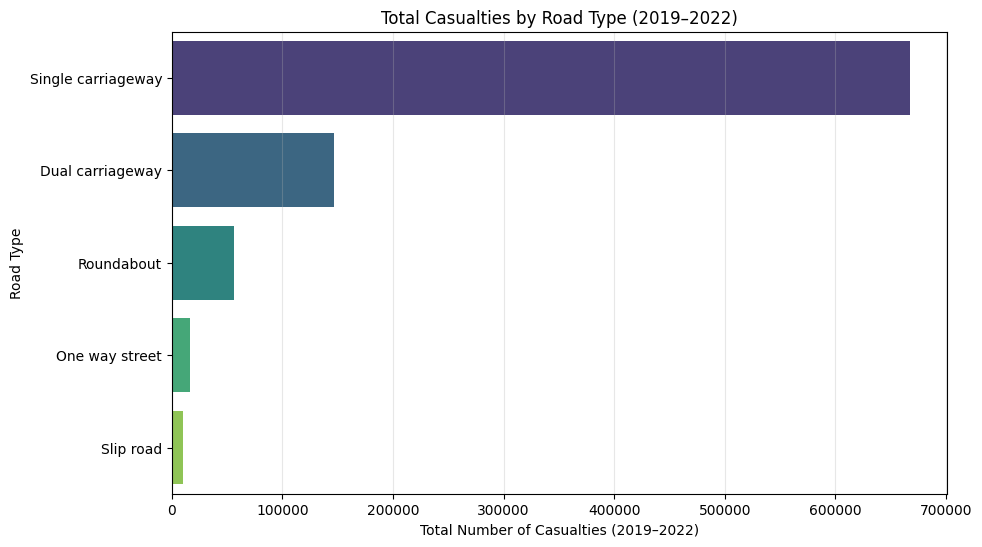

In [41]:
road_type_casualties = (
    df.groupby('Road_Type')['Number_of_Casualties']
      .sum()
      .reset_index()
      .sort_values(by='Number_of_Casualties', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=road_type_casualties,
    x='Number_of_Casualties',
    y='Road_Type',
    palette='viridis'
)

plt.xlabel('Total Number of Casualties (2019–2022)')
plt.ylabel('Road Type')
plt.title('Total Casualties by Road Type (2019–2022)')
plt.grid(axis='x', alpha=0.3)

plt.show()

<h2>Insights: The record shoow single carriageways has the highest number of casualties. Because we know that there are  mixed traffic cars, buses, motorcycles, cyclists, pedestrians use these roads on their daily lives. It means we can assume that these accidents may occur at lower speeds but higher frequency, leading to more casualties overall. </h2>

<h2> On the otherhand motorways and dual carriageways show fewer casualties, which seems unbelievable because of the higher speed limits. Maybe the reason to this is better infrastructure and controlled access, no pedestrians, fewer intersections, and separation of directions. Strict enforcement of speed cameras and traffic laws on motorways may play a role. But we can assume that maybe this road type has less accidents but it has more fatality by many reasons but the main one is overspeeding which can be deadly. </h2>